In [1]:
from pathlib import Path
import os
import sys

repo_root = Path.home() / 'Source' / 'flow-matching-mnist'
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))

In [2]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


/home/luke-padmore/miniconda3/envs/ml/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.34987926..0.60566515].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4141989..0.7209561].


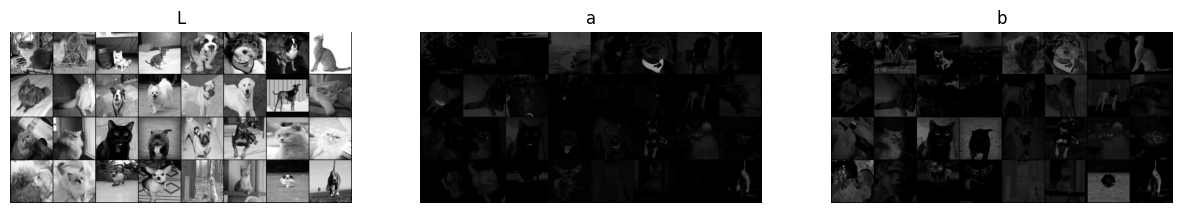

In [3]:
from src.flow_matching.utils.data_modules import OxfordPetsColouriserDataModule

dm = OxfordPetsColouriserDataModule(data_path="data")

dl = dm.train_dataloader()

batch = next(iter(dl))
def show_lab_channels(batch):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    names = ["L", "a", "b"]

    for i in range(3):
        grid = make_grid(batch[:, i:i+1], nrow=8)

        ax[i].imshow(
            grid.permute(1,2,0).squeeze().cpu(),
            cmap="gray" if i == 0 else None,
        )
        ax[i].set_title(names[i])
        ax[i].axis("off")

    plt.show()


show_lab_channels(batch[:64])

In [22]:
from lightning import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import MLFlowLogger
from lightning.pytorch.tuner import Tuner
from src.flow_matching.utils.data_modules import CIFAR10DataModule
from src.flow_matching.models.lightning import (
    ColouriserLPIPSCallback,
    InputGridCallback,
    MLFlowArtifactCallback,
    SimpleColouriserFlowMatchingModule,
)
import yaml

with open('configs/train/oxford_pets_colouriser.yaml') as f:
    config = yaml.safe_load(f)

model = SimpleColouriserFlowMatchingModule(**config['model']['init_args'])
dm = OxfordPetsColouriserDataModule(**config['data']['init_args'])

def make_trainer(*, max_epochs: int, overfit_batches=0, log_every_n_steps: int = 1):
    logger_cfg = config['trainer']['logger']['init_args']
    checkpoint_callback = ModelCheckpoint(
        dirpath='outputs/oxford_pets_colouriser/checkpoints',
        filename='best',
        monitor='val_mse_epoch',
        mode='min',
        save_top_k=1,
        save_last=True,
        auto_insert_metric_name=False,
    )
    callbacks = [
        checkpoint_callback,
        ColouriserLPIPSCallback(
            every_n_epochs=5,
            n_images=64,
            n_steps=50,
            ode_solver_name='rk4_solver',
            sample_seed=42,
        ),
        InputGridCallback(
            n_images=64,
            nrow=8,
            artifact_prefix='inputs/oxford_pets_colouriser',
        ),
        MLFlowArtifactCallback(
            model_artifact_name='SimpleColouriser',
            config_path='configs/train/oxford_pets_colouriser.yaml',
        ),
    ]
    logger = MLFlowLogger(
        experiment_name=logger_cfg['experiment_name'],
        run_name=logger_cfg['run_name'],
        tracking_uri=logger_cfg['tracking_uri'],
        save_dir=logger_cfg['save_dir'],
        log_model=False,
    )
    return Trainer(
        accelerator='auto',
        devices=1,
        default_root_dir='outputs/_colouriser',
        max_epochs=max_epochs,
        overfit_batches=overfit_batches,
        log_every_n_steps=log_every_n_steps,
        logger=logger,
        callbacks=callbacks,
        enable_checkpointing=True,
    )

tuner = Tuner(make_trainer(max_epochs=1))


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.
LR finder stopped early after 62 steps due to diverging loss.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at outputs/_colouriser/.lr_find_288ff295-ab9a-4ee1-b554-42546e2aedd3.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at outputs/_colouriser/.lr_find_288ff295-ab9a-4ee1-b554-42546e2aedd3.ckpt
Learning rate set to 2.0892961308540396e-05


🏃 View run oxford_pets_colouriser at: http://localhost:5000/#/experiments/2/runs/c7bea32a394440adb249bcd723fe49e4
🧪 View experiment at: http://localhost:5000/#/experiments/2


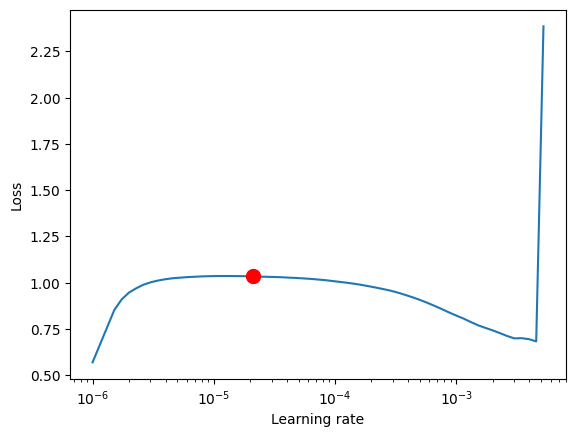

In [23]:
trainer = Trainer(
    accelerator="gpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
    limit_train_batches=100
)

lr_finder = tuner.lr_find(
    model,
    datamodule=dm,
    mode="exponential",
    min_lr=1e-6,
    max_lr=1,
)

fig = lr_finder.plot(suggest=True)
fig.show()

In [13]:
trainer = Trainer(
    accelerator="gpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
    max_epochs=1,
    num_sanity_val_steps=0,
)

tuner = Tuner(trainer)
best_bs = tuner.scale_batch_size(
    model,
    datamodule=dm,
    mode="power",        # fastest
    init_val=16,         # start near where you expect it
    max_trials=8,
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:Batch size 16 succeeded, trying batch size 32
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:Batch size 32 succeeded, trying batch size 64
INFO:pytorch_lightning.utilities.rank_zero:Batch size 64 failed, trying batch size 32
Finished batch size finder, will continue with full run using batch size 32
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /home/luke-padmore/Source/flow-matching-mnist/.scale_batch_size_94544a64-e4bc-46b7-a4f9-e1da0a117cf8.ckpt
/home/luke-padmore/miniconda3/envs/ml/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), whi

In [14]:
trainer = make_trainer(
    overfit_batches=10,
    max_epochs=10,
    log_every_n_steps=1,
)
dm.batch_size = 32
trainer.fit(model, dm)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/home/luke-padmore/miniconda3/envs/ml/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/luke-padmore/Source/flow-matching-mnist/outputs/oxford_pets_colouriser/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/luke-padmore/miniconda3/envs/ml/lib/python3.12/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explic

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss_fn   │ MSELoss          │      0 │ train │     0 │
│ 1 │ generator │ SimpleColouriser │  6.8 M │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 6.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.8 M                                                                                                
Total estimated model params size (MB): 27.016                                                                     
Modules in train mode: 224                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


/home/luke-padmore/Source/flow-matching-mnist/src/flow_matching/utils/color.py:61: UserWarning: Conversion from 
CIE-LAB, via XYZ to sRGB color space resulted in 32 negative Z values that have been clipped to zero
  [_lab2rgb(np.moveaxis(image, 0, -1)) for image in lab],

🏃 View run oxford_pets_colouriser at: http://localhost:5000/#/experiments/2/runs/e69c68a7222848a9bca6a9a0bae12a39
🧪 View experiment at: http://localhost:5000/#/experiments/2


SystemExit: 1

/home/luke-padmore/miniconda3/envs/ml/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
